In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# load general packages
import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt

# load modules related to this exercise
import Exercise_1 as ex1

# Exercise 1: Time iteration

Consider the model
$$\begin{align*}
V_{t}(M_{t}) & = & \max_{C_{t}}\left\{ \frac{C_{t}^{1-\rho}}{1-\rho}+\beta\mathbb{E}_{t}\left[V_{t+1}(M_{t+1})\right]\right\} \\
 & \text{s.t.}\\
M_{t+1} & = & R(M_{t}-C_{t})+Y_{t+1}\\
Y_{t+1} & = & \exp(\xi_{t+1})\\
\xi_{t+1} & \sim & \mathcal{N}(\mu,\sigma_{\xi}^{2})\\
A_{t}=M_{t}-C_{t} & \geq & 0
\end{align*}$$

The baseline uses $T=10$, $\beta=0.98$, $\rho=0.5$, $R=1/\beta$, initial cash-on-hand $M_1=1.5$, an upper grid bound of 10, and $\sigma_{\xi}=0.2$.

## 1. Solve the model using time iteration
Remember that optimal consumption must satisfy the Euler equation:
$$\begin{align*}
u'(C_t) = \beta R \mathbb{E}_t[u'(C_{t+1}^{\star}(M_{t+1}))]
\end{align*}$$

In [3]:
# setup
par = ex1.setup()

# solve
sol = ex1.solve_ti(par)

/Users/fzp386/Dropbox/1PROJECTS/IRS/DPcourse/2026.Michigan/LOCAL_DSE2026/02.Schjerning/Lecture_13_dcegm/exercises/ex_post/Exercise_1.py:15: RuntimeWarning: invalid value encountered in power
  return c**(-par.rho)


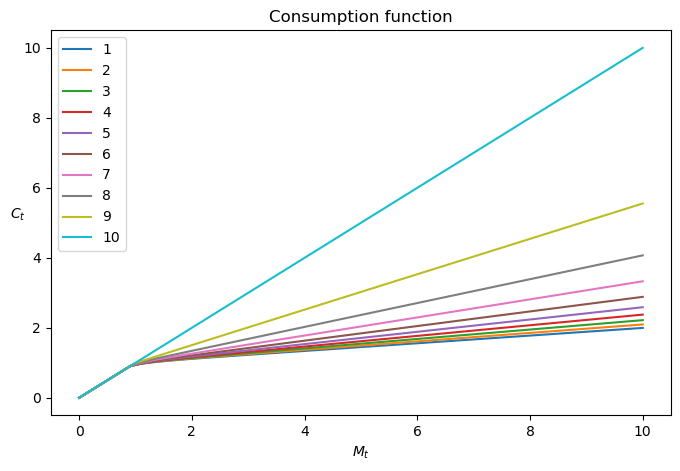

In [4]:
fig, ax = plt.subplots(figsize=(8,5))

for t in range(par.T):
    ax.plot(par.grid_M,sol.C[:,t], label=t+1)
ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$C_t$", rotation=0)
ax.set_title(f'Consumption function')
ax.legend()

## 2. Simulate a panel of $N=10{,}000$ households for $T=10$ periods and plot the mean of $C_t$. Everybody should be initialized with $M_1 = 1.5$.

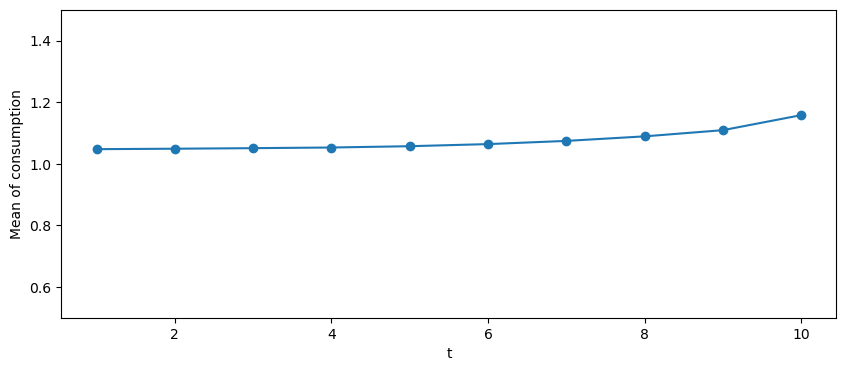

In [5]:
sim = ex1.simulate(par,sol)

def figure_sim(simC,par):
    fig, ax = plt.subplots(figsize=(10,4))# figsize is in inches...
    t_grid = [t for t in range(1,par.T+1)]    
    ax.plot(t_grid,np.mean(simC,0),'-o')
    ax.set_xlabel(f"t")
    ax.set_ylabel(f"Mean of consumption")
    ax.set_ylim(bottom=0.5,top=1.5)
    
figure_sim(sim.C,par)

## 3. Compute the Euler error and the normalized Euler error


#### Recall the Euler-error:

$$\begin{align*}
 \frac{1}{\sum_{i=1}^{N}\sum_{t=1}^{T-1}  \mathbb{1}_{\{A_{i,t}>0\}}}\sum_{i=1}^{N}\sum_{t=1}^{T-1} \mathbb{1}_{\{A_{i,t}>0\}} |\varepsilon_{i,t}|
 \end{align*}$$
 where

$$\begin{align*}
  \varepsilon_{i,t} \approx u'(C_{i,t})-\beta R \sum_{j=1}^{S} \omega_j \Big[u'\big(C_{t+1}^{\star}(R(M_{i,t}-C_{i,t})+Y_j)\big)\Big]
 \end{align*}$$
 
 and $\omega_j$ are the Gauss-Hermite weights and $Y_j$ are the associated income nodes.
 
#### Recall the normalized Euler-error:


$$\begin{align*}
 \frac{1}{\sum_{i=1}^{N}\sum_{t=1}^{T-1} \mathbb{1}_{\{A_{i,t}>0\}}}\sum_{i=1}^{N}\sum_{t=1}^{T-1} \log_{10}(|\varepsilon_{i,t}| / C_{i,t}) \mathbb{1}_{\{A_{i,t}>0 \}} 
 \end{align*}$$


In [6]:
Euler_residual = np.zeros((par.simN, par.T-1)) + np.nan
A = np.zeros((par.simN,par.T-1)) + np.nan

# 1. compute Euler errors
for t in range(par.T-1):

    m = sim.M[:, t]
    c = sim.C[:, t]
    A[: ,t] = m - c
    
    m_next = par.R*(m - c)[:, None] + par.eps[None, :] # creating a matrix with state grid points as rows and different shocks as columns
    
    interp = interpolate.interp1d(par.grid_M,sol.C[:, t+1], bounds_error=False, fill_value = "extrapolate") 
    c_next = interp(m_next)

    EMU_next = np.sum(par.eps_w[None, :]*ex1.marg_util(c_next,par), axis=1) # Expected marginal utility next period
    
    MU_now = ex1.marg_util(c,par)    # Marginal utility this period

    Euler_residual[:, t] = MU_now-par.beta*par.R*EMU_next
    
# 2. compute mean Euler error for interior points
Euler_error = np.mean(abs(Euler_residual[A>0]))
print(f'The Euler error:\t\t{Euler_error:.5f}')

# 3. compute the normalized Euler error
C = (sim.C[:, 0:par.T-1])
nom_Euler_error = np.log10(abs(Euler_residual[A>0])/(C[A>0]))   
nom_Euler_error = np.mean(nom_Euler_error)
print(f'The Normalized Euler error:\t{nom_Euler_error:.5f}')

The Euler error:		0.00036
The Normalized Euler error:	-4.87502


What is the Euler error? Why is it not exact zero?